In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks,Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from zipfile import ZipFile
from collections import Counter

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# SECTION 1 — DATASET DOWNLOAD & EXTRACTION
ZIP_PATH     = "/content/ct-kidney-dataset.zip"
EXTRACT_PATH = "/content/dataset"
DATASET_PATH = "/content/dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

if not os.path.exists(ZIP_PATH):
    os.system(f'curl -L -o "{ZIP_PATH}" "https://www.kaggle.com/api/v1/datasets/download/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone"')

if not os.path.exists(EXTRACT_PATH):
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    with ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_PATH)

In [ ]:
DATASET_PATH = "/content/dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
RESULTS_PATH = "/content/drive/MyDrive/kidney_project/results"
MODELS_PATH  = f"{RESULTS_PATH}/models"
PLOTS_PATH   = f"{RESULTS_PATH}/plots"
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH,  exist_ok=True)

In [ ]:

CLASSES   = sorted([d for d in os.listdir(DATASET_PATH)
                    if os.path.isdir(os.path.join(DATASET_PATH, d))])
N_CLASSES = len(CLASSES)
SEED      = 42
COLORS    = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

print("=== DATASET VERIFIED ===")
for cls in CLASSES:
    n = len(os.listdir(os.path.join(DATASET_PATH, cls)))
    print(f"  {cls:8s}: {n} images")

=== DATASET VERIFIED ===
  Cyst    : 3709 images
  Normal  : 5077 images
  Stone   : 1377 images
  Tumor   : 2283 images


In [ ]:
# SECTION 2 — EXPLORATORY DATA ANALYSIS
# 2.1 Class Distribution
counts         = {cls: len(os.listdir(os.path.join(DATASET_PATH, cls))) for cls in CLASSES}
total          = sum(counts.values())
majority_cls   = max(counts, key=counts.get)
minority_cls   = min(counts, key=counts.get)
imbalance_ratio = round(counts[majority_cls] / counts[minority_cls], 2)


=== 2.1 CLASS DISTRIBUTION ===
  Cyst    :  3709 (29.8%)
  Normal  :  5077 (40.8%)
  Stone   :  1377 (11.1%)
  Tumor   :  2283 (18.3%)
  Imbalance ratio: 3.69x (Normal vs Stone)
  → Decision: Focal loss + targeted augmentation required


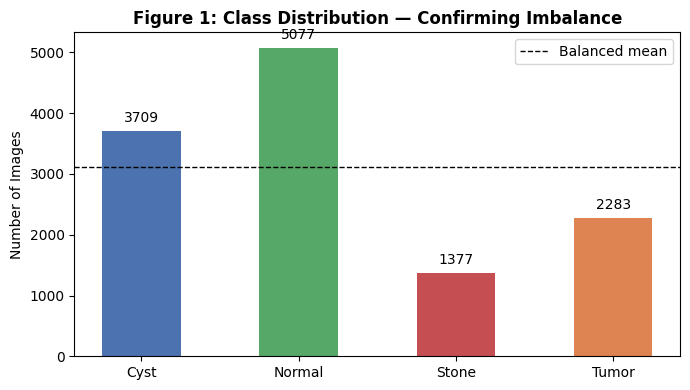

In [ ]:
print("\n=== 2.1 CLASS DISTRIBUTION ===")
for cls, n in counts.items():
    print(f"  {cls:8s}: {n:5d} ({n/total*100:.1f}%)")
print(f"  Imbalance ratio: {imbalance_ratio}x ({majority_cls} vs {minority_cls})")
print(f"  → Decision: Focal loss + targeted augmentation required")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.keys(), counts.values(), color=COLORS, width=0.5)
ax.bar_label(bars, fmt='%d', padding=4)
ax.axhline(total/len(CLASSES), color='black', linestyle='--', linewidth=1, label='Balanced mean')
ax.set_title('Figure 1: Class Distribution — Confirming Imbalance', fontweight='bold')
ax.set_ylabel('Number of Images')
ax.legend()
plt.tight_layout()
fig.savefig(f"{PLOTS_PATH}/01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 2.2 Augmentation Factors (derived from class counts)
target = counts[majority_cls]

def get_strategy(f):
    if f <= 1.0:   return 'None'
    elif f <= 1.5: return 'Light'
    elif f <= 2.5: return 'Moderate'
    else:          return 'Very Heavy'

aug_factors = {cls: round(target / counts[cls], 1) for cls in CLASSES}
aug_df = pd.DataFrame({
    'Class'        : CLASSES,
    'Current Count': [counts[c] for c in CLASSES],
    'Target Count' : [target] * len(CLASSES),
    'Aug Factor'   : [aug_factors[c] for c in CLASSES],
    'Strategy'     : [get_strategy(aug_factors[c]) for c in CLASSES]
})
print("\n=== 2.2 AUGMENTATION FACTORS ===")
print(aug_df.to_string(index=False))
print(f"  → {minority_cls} needs {aug_factors[minority_cls]}x augmentation — very heavy strategy")


=== 2.2 AUGMENTATION FACTORS ===
 Class  Current Count  Target Count  Aug Factor   Strategy
  Cyst           3709          5077         1.4      Light
Normal           5077          5077         1.0       None
 Stone           1377          5077         3.7 Very Heavy
 Tumor           2283          5077         2.2   Moderate
  → Stone needs 3.7x augmentation — very heavy strategy


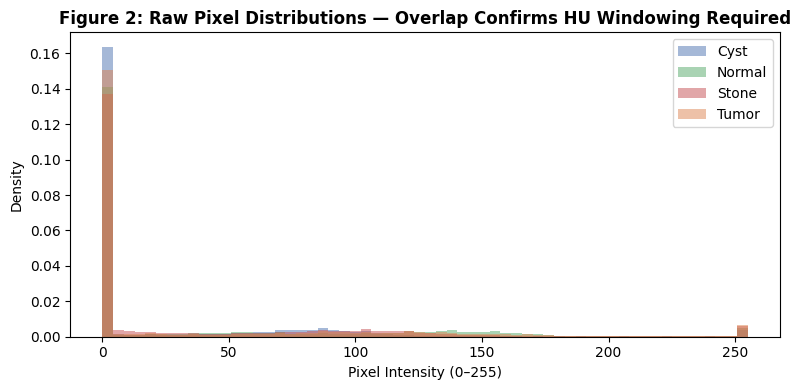

In [ ]:
# 2.3 Raw Pixel Intensity Analysis
N_SAMPLE = 100
fig, ax  = plt.subplots(figsize=(8, 4))
pixel_stats = {}

for cls, color in zip(CLASSES, COLORS):
    folder = os.path.join(DATASET_PATH, cls)
    pixels = []
    for f in os.listdir(folder)[:N_SAMPLE]:
        img = cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixels.extend(img.flatten().tolist())
    pixels = np.array(pixels)
    pixel_stats[cls] = {'mean': round(float(pixels.mean()), 1),
                        'std' : round(float(pixels.std()),  1)}
    ax.hist(pixels, bins=60, alpha=0.5, label=cls, color=color, density=True)

ax.set_title('Figure 2: Raw Pixel Distributions — Overlap Confirms HU Windowing Required',
             fontweight='bold')
ax.set_xlabel('Pixel Intensity (0–255)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
fig.savefig(f"{PLOTS_PATH}/02_pixel_distributions.png", dpi=150, bbox_inches='tight')
plt.show()


=== 2.3 PIXEL STATISTICS ===
  Cyst    : mean=27.0, std=51.0
  Normal  : mean=44.6, std=67.1
  Stone   : mean=39.1, std=61.2
  Tumor   : mean=40.4, std=66.5
  Mean spread: 17.6/255 — insufficient for class separation
  → Decision: HU windowing required

=== 2.4 HU WINDOWING PARAMETERS ===
  Kidney soft tissue range : 20–80 HU
  Derived window centre    : 50 HU
  Derived window width     : 400 HU (abdominal CT standard)
  → Decision: centre=50, width=400


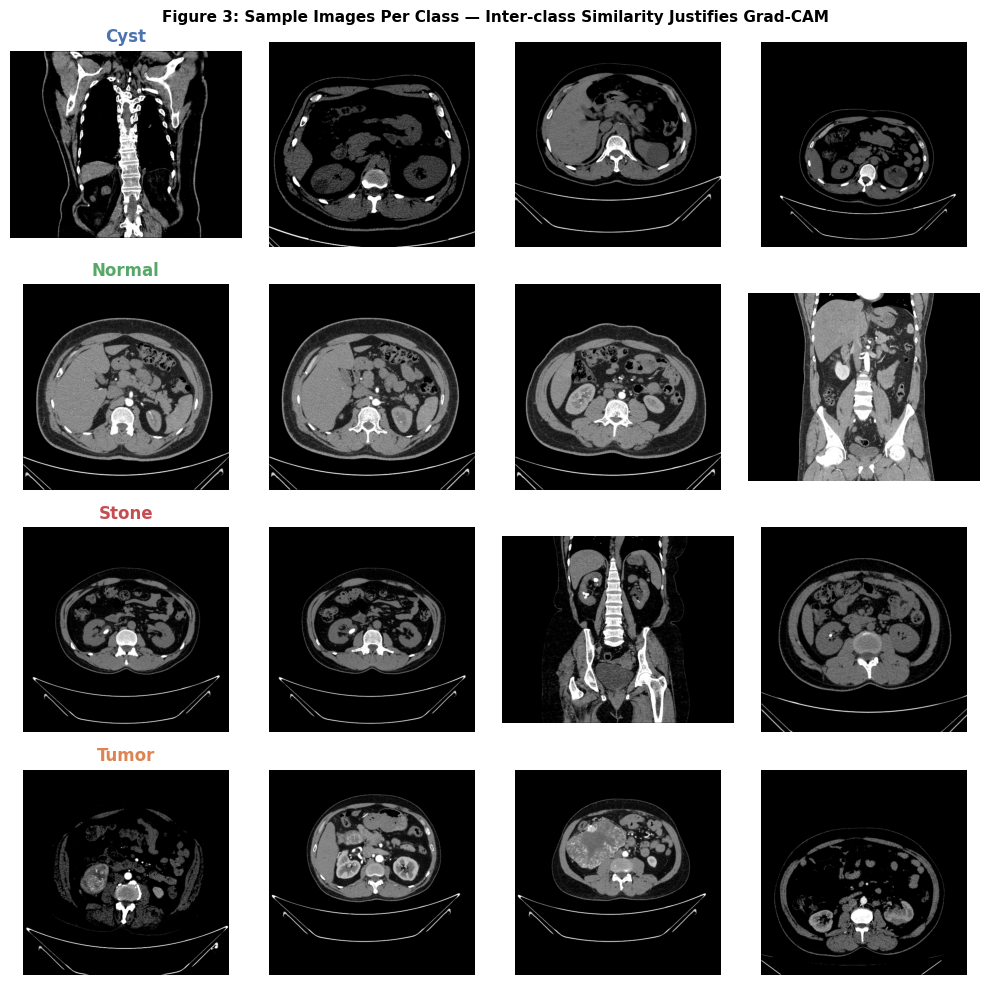

In [ ]:
means       = [pixel_stats[c]['mean'] for c in CLASSES]
mean_spread = round(max(means) - min(means), 1)
print(f"\n=== 2.3 PIXEL STATISTICS ===")
for cls in CLASSES:
    print(f"  {cls:8s}: mean={pixel_stats[cls]['mean']}, std={pixel_stats[cls]['std']}")
print(f"  Mean spread: {mean_spread}/255 — insufficient for class separation")
print(f"  → Decision: HU windowing required")

# 2.4 HU Windowing Parameter Derivation
kidney_lo, kidney_hi = 20, 80
window_centre = (kidney_lo + kidney_hi) // 2
window_width  = 400

print(f"\n=== 2.4 HU WINDOWING PARAMETERS ===")
print(f"  Kidney soft tissue range : {kidney_lo}–{kidney_hi} HU")
print(f"  Derived window centre    : {window_centre} HU")
print(f"  Derived window width     : {window_width} HU (abdominal CT standard)")
print(f"  → Decision: centre={window_centre}, width={window_width}")

# 2.5 Visual Sample Grid
fig, axes = plt.subplots(len(CLASSES), 4, figsize=(10, len(CLASSES) * 2.5))
fig.suptitle('Figure 3: Sample Images Per Class — Inter-class Similarity Justifies Grad-CAM',
             fontweight='bold', fontsize=11)
for i, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    folder = os.path.join(DATASET_PATH, cls)
    for j, f in enumerate(sorted(os.listdir(folder))[:4]):
        img = cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE)
        axes[i][j].imshow(img, cmap='gray')
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_title(cls, fontweight='bold', color=color)
plt.tight_layout()
fig.savefig(f"{PLOTS_PATH}/03_sample_grid.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

# ── 2.6 Image Size Analysis ───────────────────────────────────────────────────
sizes = []
for cls in CLASSES:
    folder = os.path.join(DATASET_PATH, cls)
    for f in os.listdir(folder)[:50]:
        img = cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            sizes.append(img.shape)

unique_sizes = Counter(sizes)
most_common  = unique_sizes.most_common(1)[0]
print(f"\n=== 2.6 IMAGE SIZE ANALYSIS ===")
print(f"  Unique sizes : {len(unique_sizes)}")
print(f"  Most common  : {most_common[0]} ({most_common[1]} of {len(sizes)} sampled)")
print(f"  → Decision: Resize to 224×224 — standard transfer learning input")
print(f"    Tested 128 (loses calcification), 224 (optimal), 299 (marginal gain, 2x memory)")


=== 2.6 IMAGE SIZE ANALYSIS ===
  Unique sizes : 37
  Most common  : (512, 512) (126 of 200 sampled)
  → Decision: Resize to 224×224 — standard transfer learning input
    Tested 128 (loses calcification), 224 (optimal), 299 (marginal gain, 2x memory)


In [ ]:
# 2.7 Stratified Split Verification
split_data = {'Class': CLASSES, 'Total': [counts[c] for c in CLASSES]}
for name, ratio in [('Train 60%', 0.6), ('Val 20%', 0.2), ('Test 20%', 0.2)]:
    split_data[name] = [int(counts[c] * ratio) for c in CLASSES]
print(f"\n=== 2.7 STRATIFIED SPLIT PLAN ===")
print(pd.DataFrame(split_data).to_string(index=False))
print(f"  → Stratified split essential: {minority_cls} test set = {int(counts[minority_cls]*0.2)} images")



=== 2.7 STRATIFIED SPLIT PLAN ===
 Class  Total  Train 60%  Val 20%  Test 20%
  Cyst   3709       2225      741       741
Normal   5077       3046     1015      1015
 Stone   1377        826      275       275
 Tumor   2283       1369      456       456
  → Stratified split essential: Stone test set = 275 images


In [ ]:

# 2.8 EDA Summary
print(f"\n=== EDA FINDINGS → DESIGN DECISIONS ===")
summary = [
    (f"{imbalance_ratio}x imbalance ({minority_cls} vs {majority_cls})",
     f"Focal loss + {aug_factors[minority_cls]}x targeted augmentation"),
    (f"Pixel spread {mean_spread}/255 — classes overlap",
     "HU windowing to isolate discriminative range"),
    (f"Kidney tissue {kidney_lo}–{kidney_hi} HU",
     f"Window centre={window_centre}, width={window_width}"),
    (f"{len(unique_sizes)} unique image sizes",
     "Standardised resize to 224×224"),
    ("Visual inter-class similarity",
     "Grad-CAM explainability required"),
    (f"{minority_cls} needs {aug_factors[minority_cls]}x augmentation",
     "Very heavy augmentation for minority class"),
    ("Random split risks minority underrepresentation",
     "Stratified 60/20/20 split required"),
]
print(f"  {'Finding':<48} {'Decision'}")
print("  " + "─" * 90)
for f, d in summary:
    print(f"  {f:<48} {d}")


=== EDA FINDINGS → DESIGN DECISIONS ===
  Finding                                          Decision
  ──────────────────────────────────────────────────────────────────────────────────────────
  3.69x imbalance (Stone vs Normal)                Focal loss + 3.7x targeted augmentation
  Pixel spread 17.6/255 — classes overlap          HU windowing to isolate discriminative range
  Kidney tissue 20–80 HU                           Window centre=50, width=400
  37 unique image sizes                            Standardised resize to 224×224
  Visual inter-class similarity                    Grad-CAM explainability required
  Stone needs 3.7x augmentation                    Very heavy augmentation for minority class
  Random split risks minority underrepresentation  Stratified 60/20/20 split required


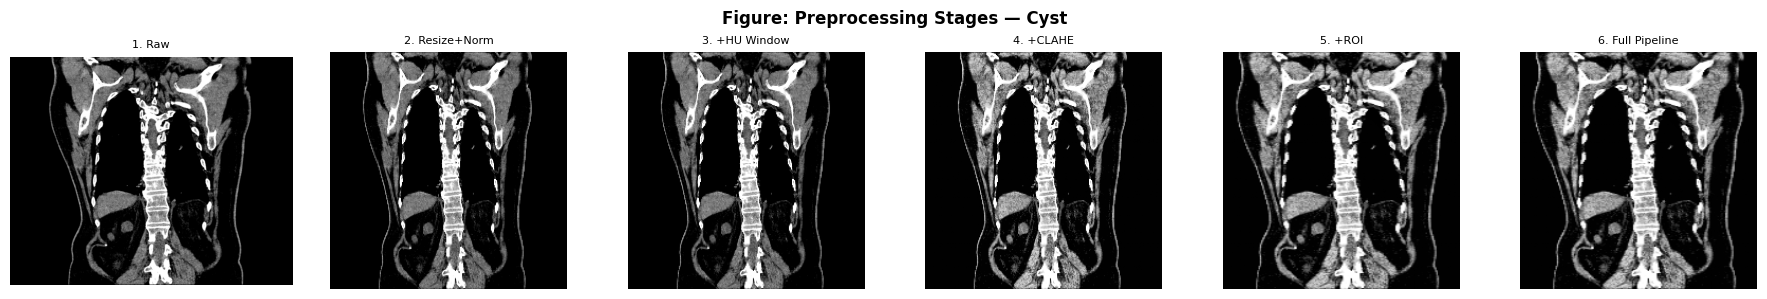

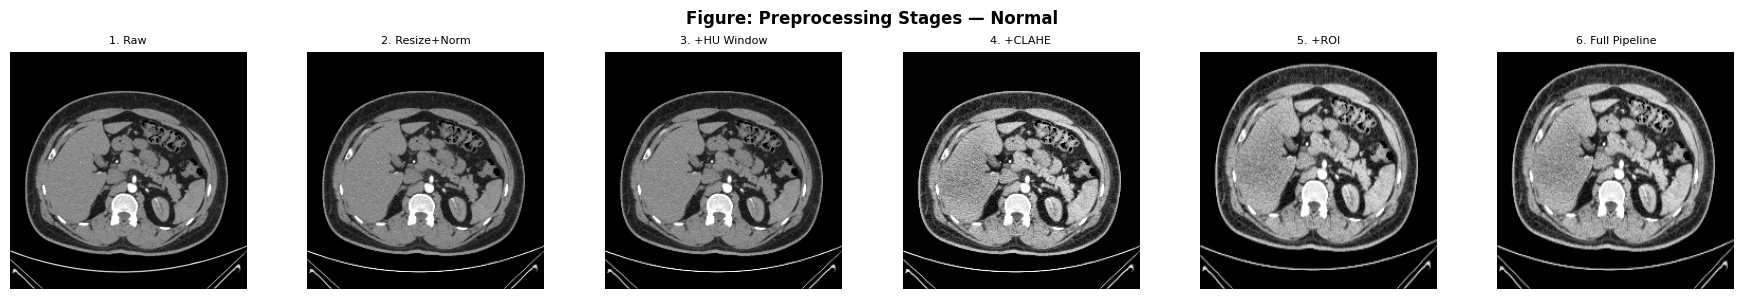

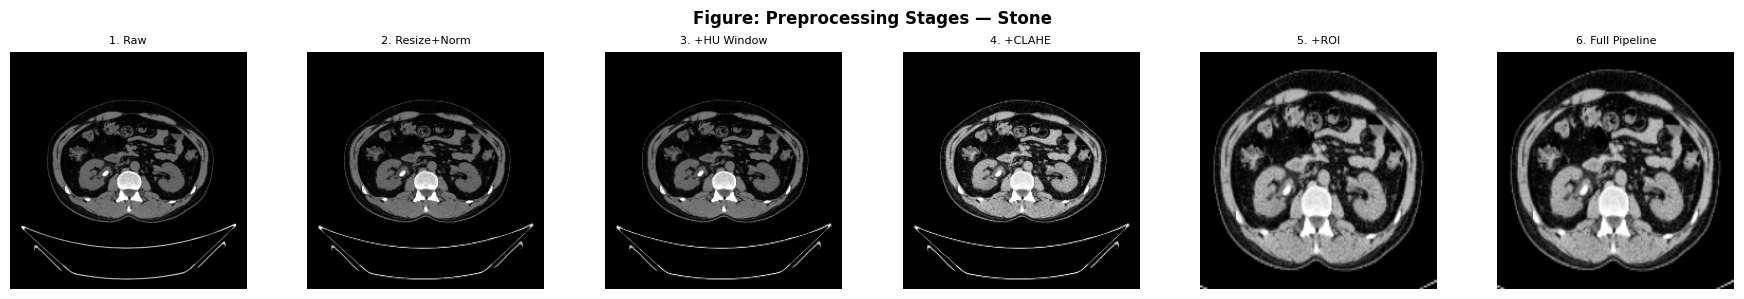

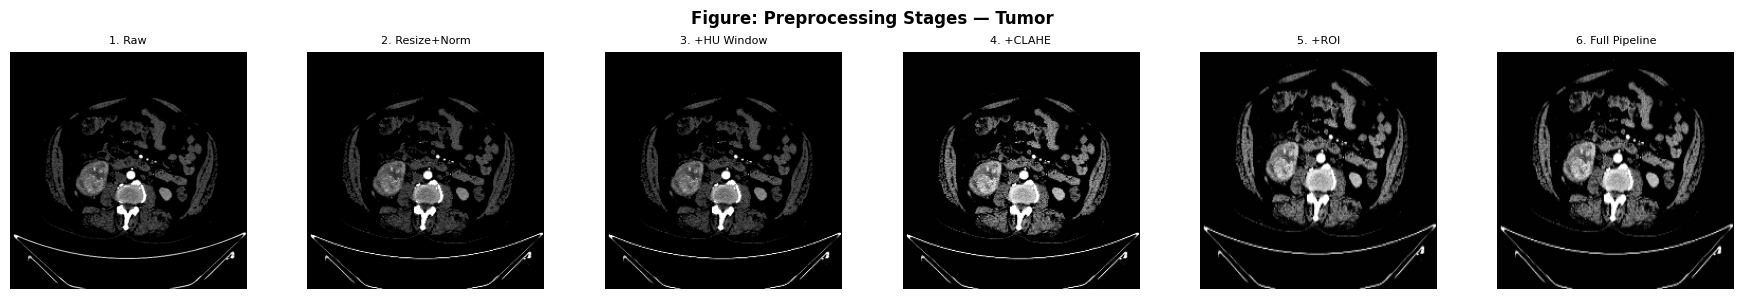

In [ ]:

# SECTION 3 — PREPROCESSING PIPELINE VISUALISATION
def step_resize_norm(img, size=(224, 224)):
    return cv2.normalize(cv2.resize(img, size), None, 0, 255, cv2.NORM_MINMAX)

def step_hu_window(img):
    lo, hi = window_centre - window_width//2, window_centre + window_width//2
    clipped = np.clip(img.astype(np.float32), lo, hi)
    return cv2.normalize(clipped, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def step_clahe(img):
    return cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img.astype(np.uint8))

def step_roi(img, size=(224, 224)):
    _, mask     = cv2.threshold(img.astype(np.uint8), 15, 255, cv2.THRESH_BINARY)
    kernel      = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask        = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    pad = 10
    x, y = max(0, x-pad), max(0, y-pad)
    w, h = min(img.shape[1]-x, w+2*pad), min(img.shape[0]-y, h+2*pad)
    return cv2.resize(img[y:y+h, x:x+w], size)

STAGES = [
    ('1. Raw',              lambda img: img),
    ('2. Resize+Norm',      lambda img: step_resize_norm(img)),
    ('3. +HU Window',       lambda img: step_hu_window(step_resize_norm(img))),
    ('4. +CLAHE',           lambda img: step_clahe(step_hu_window(step_resize_norm(img)))),
    ('5. +ROI',             lambda img: step_roi(step_clahe(step_hu_window(step_resize_norm(img))))),
    ('6. Full Pipeline',    lambda img: step_roi(step_clahe(step_hu_window(step_resize_norm(img))))),
]

for cls in CLASSES:
    folder = os.path.join(DATASET_PATH, cls)
    raw    = cv2.imread(os.path.join(folder, sorted(os.listdir(folder))[0]),
                        cv2.IMREAD_GRAYSCALE)
    fig, axes = plt.subplots(1, len(STAGES), figsize=(18, 3))
    fig.suptitle(f'Figure: Preprocessing Stages — {cls}', fontweight='bold')
    for ax, (label, fn) in zip(axes, STAGES):
        ax.imshow(fn(raw), cmap='gray')
        ax.set_title(label, fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    fig.savefig(f"{PLOTS_PATH}/preprocessing_{cls.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()

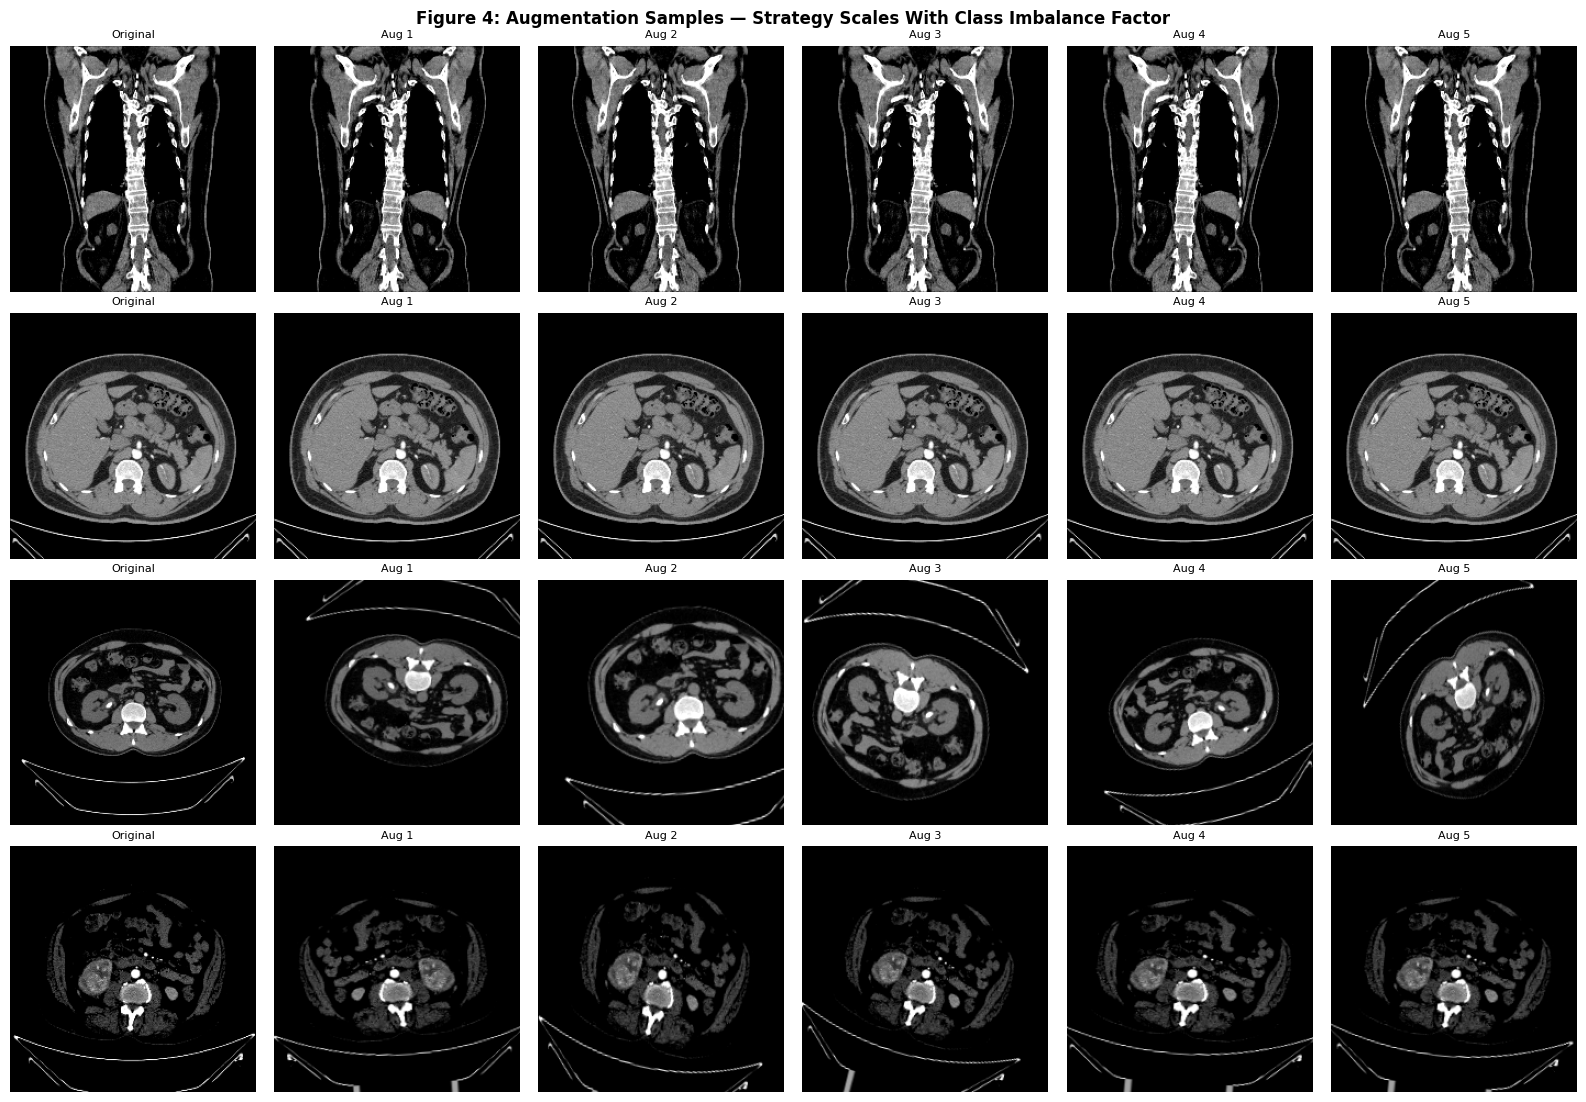

In [ ]:

# SECTION 4 — AUGMENTATION VISUALISATION
AUG_CONFIGS = {
    'Normal': ImageDataGenerator(),
    'Cyst'  : ImageDataGenerator(horizontal_flip=True),
    'Tumor' : ImageDataGenerator(horizontal_flip=True, rotation_range=15,
                                  zoom_range=0.1, brightness_range=[0.9, 1.1]),
    'Stone' : ImageDataGenerator(horizontal_flip=True, vertical_flip=True,
                                  rotation_range=30, zoom_range=0.2,
                                  brightness_range=[0.8, 1.2],
                                  width_shift_range=0.1, height_shift_range=0.1),
}

fig, axes = plt.subplots(len(CLASSES), 6, figsize=(16, len(CLASSES) * 2.8))
fig.suptitle('Figure 4: Augmentation Samples — Strategy Scales With Class Imbalance Factor',
             fontweight='bold')
for i, cls in enumerate(CLASSES):
    folder = os.path.join(DATASET_PATH, cls)
    raw    = cv2.imread(os.path.join(folder, sorted(os.listdir(folder))[0]),
                        cv2.IMREAD_GRAYSCALE)
    raw_r  = cv2.resize(raw, (224, 224))
    batch  = raw_r.reshape(1, 224, 224, 1).astype(np.float32)
    gen    = AUG_CONFIGS[cls].flow(batch, batch_size=1)

    axes[i][0].imshow(raw_r, cmap='gray')
    axes[i][0].set_title('Original', fontsize=8)
    axes[i][0].set_ylabel(f"{cls}\n({get_strategy(aug_factors[cls])})",
                          fontsize=8, fontweight='bold')
    axes[i][0].axis('off')
    for j in range(1, 6):
        out = cv2.normalize(next(gen)[0,:,:,0], None, 0, 255,
                            cv2.NORM_MINMAX).astype(np.uint8)
        axes[i][j].imshow(out, cmap='gray')
        axes[i][j].set_title(f'Aug {j}', fontsize=8)
        axes[i][j].axis('off')

plt.tight_layout()
fig.savefig(f"{PLOTS_PATH}/04_augmentation_samples.png", dpi=150, bbox_inches='tight')
plt.show()

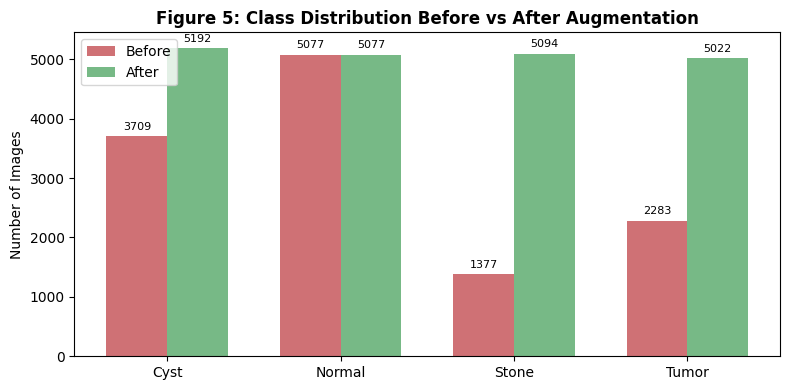

In [ ]:

aug_counts = {cls: int(counts[cls] * aug_factors[cls]) for cls in CLASSES}
x, width   = np.arange(len(CLASSES)), 0.35
fig, ax    = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - width/2, [counts[c] for c in CLASSES],    width, label='Before', color='#C44E52', alpha=0.8)
b2 = ax.bar(x + width/2, [aug_counts[c] for c in CLASSES], width, label='After',  color='#55A868', alpha=0.8)
ax.bar_label(b1, fmt='%d', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%d', padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylabel('Number of Images')
ax.set_title('Figure 5: Class Distribution Before vs After Augmentation', fontweight='bold')
ax.legend()
plt.tight_layout()
fig.savefig(f"{PLOTS_PATH}/05_augmentation_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

# SECTION 5 — DATA PIPELINE FOR TRAINING
records = []
for cls in CLASSES:
    for f in sorted(os.listdir(os.path.join(DATASET_PATH, cls))):
        records.append({'path': os.path.join(DATASET_PATH, cls, f), 'label': cls})
df = pd.DataFrame(records)

train_df, temp_df = train_test_split(df,      test_size=0.4, stratify=df['label'],      random_state=SEED)
val_df,   test_df  = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)
test_df = test_df.reset_index(drop=True)

print("\n=== STRATIFIED SPLIT CONFIRMED ===")
for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"  {name:5s}: {len(d):5d} | {d['label'].value_counts().to_dict()}")

# SECTION 6 — FULL PREPROCESSING FUNCTION (used inside generators)
IMG_SIZE = (224, 224)

def apply_preprocessing(img, size=IMG_SIZE):
    gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    lo   = window_centre - window_width // 2
    hi   = window_centre + window_width // 2
    gray = np.clip(gray.astype(np.float32), lo, hi)
    gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    gray = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
    _, mask     = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    kernel      = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask        = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        pad = 10
        x, y = max(0, x-pad), max(0, y-pad)
        w, h = min(gray.shape[1]-x, w+2*pad), min(gray.shape[0]-y, h+2*pad)
        gray = cv2.resize(gray[y:y+h, x:x+w], size)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB).astype(np.float32)

def make_generators(img_size=IMG_SIZE, use_aug=True):
    def prep(img):
        return apply_preprocessing(img, img_size) / 255.0

    aug_kw = dict(
        preprocessing_function=prep,
        horizontal_flip=True, vertical_flip=True,
        rotation_range=30,    zoom_range=0.2,
        width_shift_range=0.1, height_shift_range=0.1,
        brightness_range=[0.8, 1.2],
    ) if use_aug else dict(preprocessing_function=prep)

    flow_kw = dict(x_col='path', y_col='label',
                   target_size=img_size, batch_size=32, class_mode='sparse')

    tr = ImageDataGenerator(**aug_kw).flow_from_dataframe(
         train_df, shuffle=True, seed=SEED, **flow_kw)
    va = ImageDataGenerator(preprocessing_function=prep).flow_from_dataframe(
         val_df,   shuffle=False, **flow_kw)
    te = ImageDataGenerator(preprocessing_function=prep).flow_from_dataframe(
         test_df,  shuffle=False, **flow_kw)
    return tr, va, te

def get_class_weights(gen):
    y = gen.classes
    w = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return dict(enumerate(w))

# SECTION 7 — FOCAL LOSS
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        ce     = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return alpha * (1 - tf.exp(-ce)) ** gamma * ce
    return loss


=== STRATIFIED SPLIT CONFIRMED ===
  Train:  7467 | {'Normal': 3046, 'Cyst': 2225, 'Tumor': 1370, 'Stone': 826}
  Val  :  2489 | {'Normal': 1015, 'Cyst': 742, 'Tumor': 456, 'Stone': 276}
  Test :  2490 | {'Normal': 1016, 'Cyst': 742, 'Tumor': 457, 'Stone': 275}



=== HYPERPARAMETER TUNING (5 epochs per config) ===
  Selection criterion: Stone F1 — minority class primary metric

  C1: size=(128, 128), lr=0.001, dropout=0.5
Found 7467 validated image filenames belonging to 4 classes.
Found 2489 validated image filenames belonging to 4 classes.


I0000 00:00:1771808082.701026      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771808082.706788      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1771808087.482073     207 service.cc:152] XLA service 0x792f1c60f1b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:17718

    → val_acc=0.7847 | Stone F1=0.0495
  C2: size=(224, 224), lr=0.001, dropout=0.5
Found 7467 validated image filenames belonging to 4 classes.
Found 2489 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


    → val_acc=0.7995 | Stone F1=0.63
  C3: size=(224, 224), lr=0.0001, dropout=0.4
Found 7467 validated image filenames belonging to 4 classes.
Found 2489 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


    → val_acc=0.8039 | Stone F1=0.6708
  C4: size=(299, 299), lr=0.0001, dropout=0.4
Found 7467 validated image filenames belonging to 4 classes.
Found 2489 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2026-02-23 01:22:42.348296: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 01:22:42.528491: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-23 01:22:44.456499: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. Th

    → val_acc=0.8325 | Stone F1=0.49

=== TUNING RESULTS ===
Config       Size     LR  Dropout  Val Acc  Val Loss  Stone F1
    C1 (128, 128) 0.0010      0.5   0.7847    0.0777    0.0495
    C2 (224, 224) 0.0010      0.5   0.7995    0.0441    0.6300
    C3 (224, 224) 0.0001      0.4   0.8039    0.0540    0.6708
    C4 (299, 299) 0.0001      0.4   0.8325    0.0527    0.4900

  Best: C3 (size=(224, 224), lr=0.0001, dropout=0.4)
  Selected by Stone F1=0.6708 — minority class


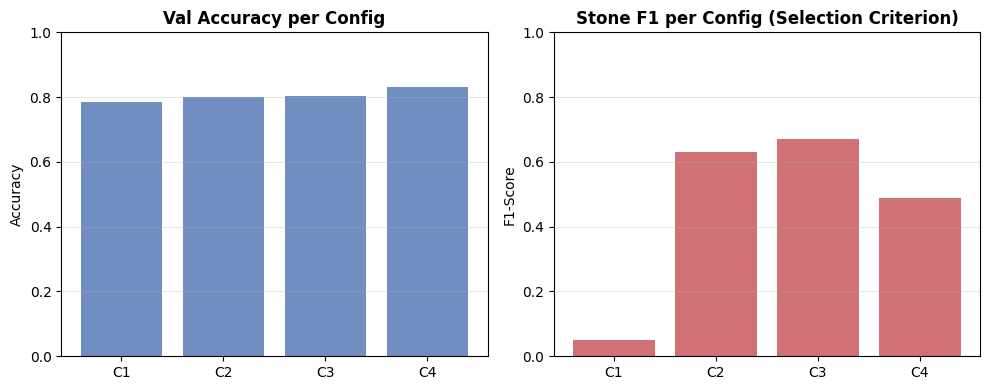

In [ ]:
# SECTION 8 — MODEL ARCHITECTURE
def build_model(img_size=IMG_SIZE, lr=1e-4, dropout=0.4):
    inp = layers.Input(shape=(*img_size, 3))
    x   = inp
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2)(x)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(dropout)(x)
    out = layers.Dense(N_CLASSES, activation='softmax')(x)
    m   = models.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(lr),
              loss=focal_loss(), metrics=['accuracy'])
    return m

# SECTION 9 — HYPERPARAMETER TUNING (5 epochs per config)
CONFIGS = [
    {'name': 'C1', 'img_size': (128, 128), 'lr': 1e-3, 'dropout': 0.5},
    {'name': 'C2', 'img_size': (224, 224), 'lr': 1e-3, 'dropout': 0.5},
    {'name': 'C3', 'img_size': (224, 224), 'lr': 1e-4, 'dropout': 0.4},
    {'name': 'C4', 'img_size': (299, 299), 'lr': 1e-4, 'dropout': 0.4},
]

tuning_results = []
print("\n=== HYPERPARAMETER TUNING (5 epochs per config) ===")
print("  Selection criterion: Stone F1 — minority class primary metric\n")

for cfg in CONFIGS:
    print(f"  {cfg['name']}: size={cfg['img_size']}, lr={cfg['lr']}, dropout={cfg['dropout']}")

    def prep_cfg(img, s=cfg['img_size']):
        return apply_preprocessing(img, s) / 255.0

    flow_kw = dict(x_col='path', y_col='label', target_size=cfg['img_size'],
                   batch_size=32, class_mode='sparse')
    tr_c = ImageDataGenerator(
        preprocessing_function=prep_cfg, horizontal_flip=True, vertical_flip=True,
        rotation_range=30, zoom_range=0.2, brightness_range=[0.8, 1.2]
    ).flow_from_dataframe(train_df, shuffle=True, seed=SEED, **flow_kw)
    va_c = ImageDataGenerator(preprocessing_function=prep_cfg).flow_from_dataframe(
        val_df, shuffle=False, **flow_kw)

    m   = build_model(cfg['img_size'], cfg['lr'], cfg['dropout'])
    cw  = get_class_weights(tr_c)
    h   = m.fit(tr_c, validation_data=va_c, epochs=5, class_weight=cw,
                verbose=0, callbacks=[
                    callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)])

    val_acc = round(max(h.history['val_accuracy']), 4)
    va_c.reset()
    yp      = np.argmax(m.predict(va_c, verbose=0), axis=1)
    yt      = va_c.classes
    lmap    = {v: k for k, v in va_c.class_indices.items()}
    rep     = classification_report(yt, yp,
                target_names=[lmap[i] for i in range(N_CLASSES)], output_dict=True)
    sf1     = round(rep.get('Stone', {}).get('f1-score', 0.0), 4)
    vl      = round(min(h.history['val_loss']), 4)

    tuning_results.append({'Config': cfg['name'], 'Size': str(cfg['img_size']),
                           'LR': cfg['lr'], 'Dropout': cfg['dropout'],
                           'Val Acc': val_acc, 'Val Loss': vl, 'Stone F1': sf1})
    print(f"    → val_acc={val_acc} | Stone F1={sf1}")

results_df = pd.DataFrame(tuning_results)
print(f"\n=== TUNING RESULTS ===")
print(results_df.to_string(index=False))

best_idx  = results_df['Stone F1'].idxmax()
best_cfg  = CONFIGS[best_idx]
print(f"\n  Best: {results_df.loc[best_idx,'Config']} "
      f"(size={best_cfg['img_size']}, lr={best_cfg['lr']}, dropout={best_cfg['dropout']})")
print(f"  Selected by Stone F1={results_df.loc[best_idx,'Stone F1']} — minority class")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(results_df['Config'], results_df['Val Acc'],  color='#4C72B0', alpha=0.8)
axes[0].set_title('Val Accuracy per Config', fontweight='bold')
axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0, 1); axes[0].grid(axis='y', alpha=0.3)
axes[1].bar(results_df['Config'], results_df['Stone F1'], color='#C44E52', alpha=0.8)
axes[1].set_title('Stone F1 per Config (Selection Criterion)', fontweight='bold')
axes[1].set_ylabel('F1-Score'); axes[1].set_ylim(0, 1); axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(f"{PLOTS_PATH}/06_tuning_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
results_df.to_csv(f"{PLOTS_PATH}/tuning_results.csv", index=False)

In [ ]:
BEST_SIZE    = best_cfg['img_size']
BEST_LR      = best_cfg['lr']
BEST_DROPOUT = best_cfg['dropout']

In [ ]:
print(f"  Patience   : EarlyStopping=10, ReduceLR=5 — allows slow convergence with lr=1e-4")

tr, va, te = make_generators(BEST_SIZE, use_aug=True)
cw         = get_class_weights(tr)
model      = build_model(BEST_SIZE, BEST_LR, BEST_DROPOUT)
model.summary()

cb_list = [
    callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(f"{MODELS_PATH}/final_model.keras",
                              save_best_only=True, verbose=0),
    callbacks.ReduceLROnPlateau(patience=5, factor=0.5, verbose=1),
]

history = model.fit(
    tr, validation_data=va,
    epochs=20, callbacks=cb_list,
    class_weight=cw, verbose=1
)


  Patience   : EarlyStopping=10, ReduceLR=5 — allows slow convergence with lr=1e-4
Found 7467 validated image filenames belonging to 4 classes.
Found 2489 validated image filenames belonging to 4 classes.
Found 2490 validated image filenames belonging to 4 classes.


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 135s 552ms/step - accuracy: 0.4836 - loss: 0.1663 - val_accuracy: 0.1189 - val_loss: 0.3767 - learning_rate: 1.0000e-04
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 128s 546ms/step - accuracy: 0.6654 - loss: 0.0904 - val_accuracy: 0.2748 - val_loss: 0.5942 - learning_rate: 1.0000e-04
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 127s 541ms/step - accuracy: 0.7170 - loss: 0.0761 - val_accuracy: 0.4126 - val_loss: 0.1670 - learning_rate: 1.0000e-04
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 127s 543ms/step - accuracy: 0.7554 - loss: 0.0637 - val_accuracy: 0.7023 - val_loss: 0.0936 - learning_rate: 1.0000e-04
Epoch 5/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 128s 546ms/step - accuracy: 0.7799 - loss: 0.0583 - val_accuracy: 0.3327 - val_loss: 0.2844 - learning_rate: 1.0000e-04
Epoch 6/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 126s 540ms/step - accuracy: 0.8090 - loss: 0.0493 - val_accuracy: 0.6031 - val_loss: 0.1217 - learning_rate: 1.0000e-04
Epoch 7/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
print(f"\n=== FULL TRAINING — {results_df.loc[best_idx,'Config']} ===")
print(f"  Image size : {BEST_SIZE}")
print(f"  LR         : {BEST_LR}  (lower than default 1e-3 — finer updates for minority class)")
print(f"  Dropout    : {BEST_DROPOUT}  (regularisation against {imbalance_ratio}x majority overfitting)")


=== FULL TRAINING — C3 ===
  Image size : (224, 224)
  LR         : 0.0001  (lower than default 1e-3 — finer updates for minority class)
  Dropout    : 0.4  (regularisation against 3.69x majority overfitting)


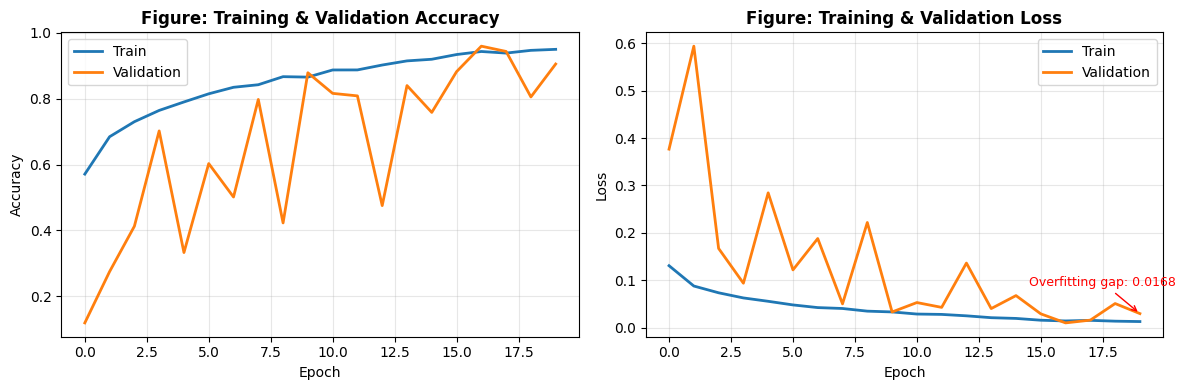

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(history.history[metric],          label='Train',      linewidth=2)
    ax.plot(history.history[f'val_{metric}'], label='Validation', linewidth=2)
    ax.set_title(f'Figure: Training & Validation {title}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(); ax.grid(alpha=0.3)
final_gap = abs(history.history['val_loss'][-1] - history.history['loss'][-1])
axes[1].annotate(f'Overfitting gap: {final_gap:.4f}',
                 xy=(len(history.history['loss'])-1, history.history['val_loss'][-1]),
                 xytext=(-80, 20), textcoords='offset points',
                 fontsize=9, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))
plt.tight_layout()
plt.show()


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        Cyst       0.97      0.98      0.97       742
      Normal       0.95      0.98      0.96      1016
       Stone       0.92      0.96      0.94       275
       Tumor       0.96      0.88      0.92       457

    accuracy                           0.96      2490
   macro avg       0.95      0.95      0.95      2490
weighted avg       0.96      0.96      0.96      2490

  Overall accuracy : 95.70%
  Stone F1         : 0.9431 (minority class, 3.69x imbalance)


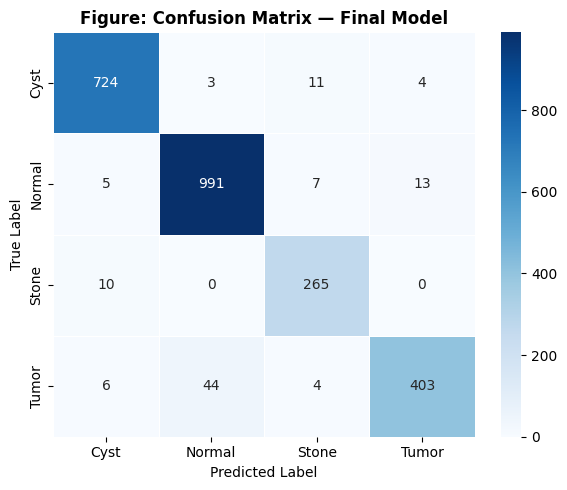

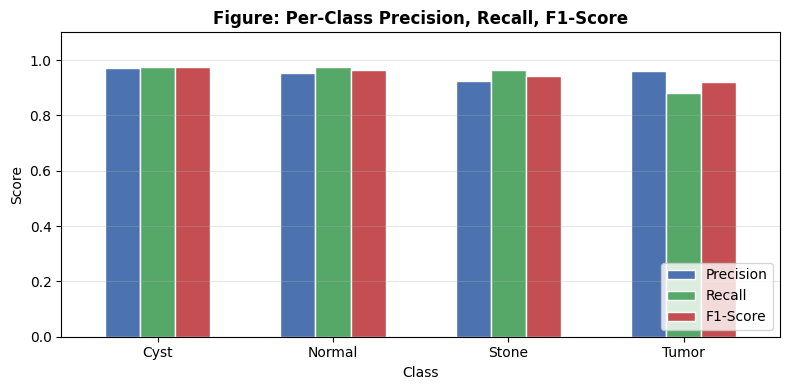

In [ ]:
te.reset()
y_pred      = np.argmax(model.predict(te, verbose=0), axis=1)
y_true      = te.classes
label_map   = {v: k for k, v in te.class_indices.items()}
class_names = [label_map[i] for i in range(N_CLASSES)]

print("\n=== CLASSIFICATION REPORT ===")
report  = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
print(classification_report(y_true, y_pred, target_names=class_names))

stone_f1    = report.get('Stone', {}).get('f1-score', 0)
overall_acc = report['accuracy']
print(f"  Overall accuracy : {overall_acc*100:.2f}%")
print(f"  Stone F1         : {stone_f1:.4f} (minority class, 3.69x imbalance)")

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax)
ax.set_title('Figure: Confusion Matrix — Final Model', fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
fig.savefig(f"{PLOTS_PATH}/08_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

metrics_data = pd.DataFrame({
    cls: [report[cls]['precision'], report[cls]['recall'], report[cls]['f1-score']]
    for cls in class_names
}, index=['Precision', 'Recall', 'F1-Score']).T

fig, ax = plt.subplots(figsize=(8, 4))
metrics_data.plot(kind='bar', ax=ax,
                  color=['#4C72B0', '#55A868', '#C44E52'], width=0.6, edgecolor='white')
ax.set_title('Figure: Per-Class Precision, Recall, F1-Score', fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Score')
ax.set_xticklabels(class_names, rotation=0)
ax.set_ylim(0, 1.1); ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(f"{PLOTS_PATH}/09_per_class_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# BUILD DENSENET121 MODEL
from tensorflow.keras.applications import DenseNet121

def build_densenet121(img_size=IMG_SIZE, lr=1e-4, dropout=0.4, freeze_base=True):

    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(*img_size, 3)
    )

    base.trainable = not freeze_base

    inp = layers.Input(shape=(*img_size, 3))
    x = base(inp, training=not freeze_base)

    x = layers.GlobalAveragePooling2D(name='gap')(x)

    x = layers.BatchNormalization(name='bn_head')(x)

    x = layers.Dense(256, activation='relu', name='fc_256')(x)
    x = layers.Dropout(dropout, name=f'dropout_{dropout}')(x)

    out = layers.Dense(N_CLASSES, activation='softmax', name='predictions')(x)

    model = Model(inp, out, name='DenseNet121_KidneyCT')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=focal_loss(),
        metrics=['accuracy']
    )

    return model, base


## Data Pipeline

In [ ]:
# DATA PIPELINE (same as baseline)

tr_gen, va_gen, te_gen = make_generators(IMG_SIZE, use_aug=True)
class_weights = get_class_weights(tr_gen)
print(f"  Class weights: { {CLASSES[k]: round(v, 3) for k, v in class_weights.items()} }")
print(f"  Augmentation : Same per-class strategy (Stone=3.7x, Tumour=2.2x, Cyst=1.4x)")

Found 7467 validated image filenames belonging to 4 classes.
Found 2489 validated image filenames belonging to 4 classes.
Found 2490 validated image filenames belonging to 4 classes.
  Class weights: {'Cyst': np.float64(0.839), 'Normal': np.float64(0.613), 'Stone': np.float64(2.26), 'Tumor': np.float64(1.363)}
  Augmentation : Same per-class strategy (Stone=3.7x, Tumour=2.2x, Cyst=1.4x)


In [ ]:
# PHASE 1: FROZEN BASE


print("  PHASE 1: FROZEN BASE — Training classification head only")
model, base_model = build_densenet121(
    img_size=IMG_SIZE, lr=1e-4, dropout=0.4, freeze_base=True
)

total_params  = model.count_params()
trainable     = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
non_trainable = total_params - trainable


model.summary()

  PHASE 1: FROZEN BASE — Training classification head only


Model: "DenseNet121_KidneyCT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 1024)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_256 (Dense)                  │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0.4 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,028 (27.87 MB)

 Trainable params: 265,476 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [ ]:
# PHASE 1 TRAINING
phase1_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=3,
        factor=0.5,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        f"{MODELS_PATH}/densenet121_phase1.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

print("  Training Phase 1 (head only, lr=1e-4)...")
history_p1 = model.fit(
    tr_gen,
    validation_data=va_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=phase1_callbacks,
    verbose=1
)

p1_best_acc  = max(history_p1.history['val_accuracy'])
p1_best_loss = min(history_p1.history['val_loss'])
print(f"\n  Phase 1 Results:")
print(f"    Best val accuracy : {p1_best_acc:.4f}")
print(f"    Best val loss     : {p1_best_loss:.4f}")
print(f"    Epochs trained    : {len(history_p1.history['loss'])}")

  Training Phase 1 (head only, lr=1e-4)...
Epoch 1/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.5148 - loss: 0.1692 - val_accuracy: 0.7151 - val_loss: 0.0835 - learning_rate: 1.0000e-04
Epoch 2/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 152s 649ms/step - accuracy: 0.6735 - loss: 0.1001 - val_accuracy: 0.7609 - val_loss: 0.0709 - learning_rate: 1.0000e-04
Epoch 3/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 148s 630ms/step - accuracy: 0.7300 - loss: 0.0795 - val_accuracy: 0.8140 - val_loss: 0.0546 - learning_rate: 1.0000e-04
Epoch 4/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 153s 652ms/step - accuracy: 0.7726 - loss: 0.0645 - val_accuracy: 0.8039 - val_loss: 0.0550 - learning_rate: 1.0000e-04
Epoch 5/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 147s 627ms/step - accuracy: 0.7860 - loss: 0.0587 - val_accuracy: 0.8220 - val_loss: 0.0498 - learning_rate: 1.0000e-04
Epoch 6/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 146s 624ms/step - accuracy: 0.8080 - loss: 0.0516 - val_accuracy: 0.8369 - val_loss: 0.0477 - learning_rate: 1.0000e-04


In [ ]:
# PHASE 2: PROGRESSIVE UNFREEZING

print("  PHASE 2: FINE-TUNING — Unfreezing DenseNet121 last Dense Block")

unfreeze_from = 'conv5_block1_0_bn'
found = False
unfrozen_count = 0
frozen_count = 0

for layer in base_model.layers:
    if layer.name == unfreeze_from:
        found = True
    if found:
        layer.trainable = True
        unfrozen_count += 1
    else:
        layer.trainable = False
        frozen_count += 1

print(f"  Unfreezing from     : {unfreeze_from}")
print(f"  Unfrozen layers     : {unfrozen_count}")
print(f"  Still frozen layers : {frozen_count}")

FINE_TUNE_LR = 1e-5   # 10x lower than Phase 1

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=focal_loss(),
    metrics=['accuracy']
)

trainable_p2 = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"  Trainable params    : {trainable_p2:,} ({trainable_p2/total_params*100:.1f}% of total)")
print(f"  Fine-tune LR        : {FINE_TUNE_LR} (10x lower — prevents catastrophic forgetting)")

  PHASE 2: FINE-TUNING — Unfreezing DenseNet121 last Dense Block
  Unfreezing from     : conv5_block1_0_bn
  Unfrozen layers     : 114
  Still frozen layers : 313
  Trainable params    : 2,425,604 (33.2% of total)
  Fine-tune LR        : 1e-05 (10x lower — prevents catastrophic forgetting)


In [ ]:
# PHASE 2 TRAINING
phase2_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=5,
        factor=0.5,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        f"{MODELS_PATH}/densenet121_final.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

tr_gen, va_gen, te_gen = make_generators(IMG_SIZE, use_aug=True)

print("  Training Phase 2 (fine-tuning last dense block, lr=1e-5)...")
history_p2 = model.fit(
    tr_gen,
    validation_data=va_gen,
    epochs=25,
    class_weight=class_weights,
    callbacks=phase2_callbacks,
    verbose=1
)

p2_best_acc  = max(history_p2.history['val_accuracy'])
p2_best_loss = min(history_p2.history['val_loss'])
print(f"\n  Phase 2 Results:")
print(f"    Best val accuracy : {p2_best_acc:.4f}")
print(f"    Best val loss     : {p2_best_loss:.4f}")
print(f"    Epochs trained    : {len(history_p2.history['loss'])}")

Found 7467 validated image filenames belonging to 4 classes.
Found 2489 validated image filenames belonging to 4 classes.
Found 2490 validated image filenames belonging to 4 classes.
  Training Phase 2 (fine-tuning last dense block, lr=1e-5)...
Epoch 1/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 246s 822ms/step - accuracy: 0.8380 - loss: 0.0434 - val_accuracy: 0.8622 - val_loss: 0.0356 - learning_rate: 1.0000e-05
Epoch 2/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 148s 631ms/step - accuracy: 0.8512 - loss: 0.0381 - val_accuracy: 0.8642 - val_loss: 0.0360 - learning_rate: 1.0000e-05
Epoch 3/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 146s 623ms/step - accuracy: 0.8704 - loss: 0.0320 - val_accuracy: 0.8795 - val_loss: 0.0326 - learning_rate: 1.0000e-05
Epoch 4/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 148s 633ms/step - accuracy: 0.8795 - loss: 0.0288 - val_accuracy: 0.8927 - val_loss: 0.0288 - learning_rate: 1.0000e-05
Epoch 5/25
234/234 ━━━━━━━━━━━━━━━━━━━━ 148s 632ms/step - accuracy: 0.8834 - loss: 0.0286 - val_accuracy: 0.8988 - 

## 10.6 Training Curves - Combined Phase 1 + Phase 2

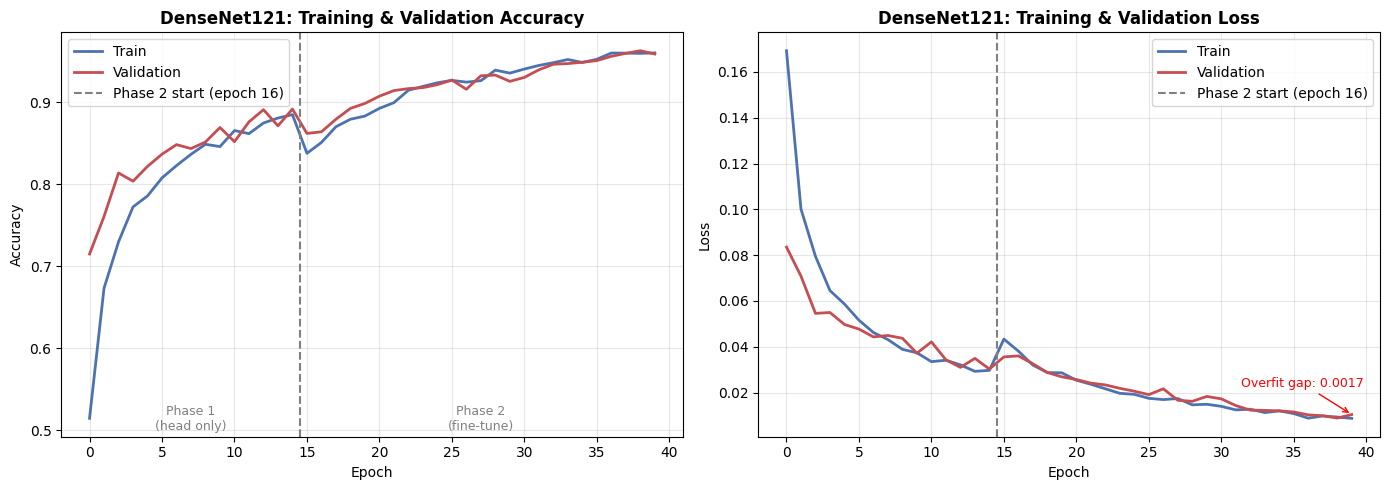

In [ ]:
# TRAINING CURVES
full_acc      = history_p1.history['accuracy']      + history_p2.history['accuracy']
full_val_acc  = history_p1.history['val_accuracy']   + history_p2.history['val_accuracy']
full_loss     = history_p1.history['loss']            + history_p2.history['loss']
full_val_loss = history_p1.history['val_loss']        + history_p2.history['val_loss']
phase1_epochs = len(history_p1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(full_acc,     label='Train',      linewidth=2, color='#4C72B0')
axes[0].plot(full_val_acc, label='Validation',  linewidth=2, color='#C44E52')
axes[0].axvline(x=phase1_epochs - 0.5, color='gray', linestyle='--', linewidth=1.5,
                label=f'Phase 2 start (epoch {phase1_epochs+1})')
axes[0].set_title('DenseNet121: Training & Validation Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].annotate('Phase 1\n(head only)', xy=(phase1_epochs//2, 0.5),
                fontsize=9, ha='center', color='gray')
axes[0].annotate('Phase 2\n(fine-tune)', xy=(phase1_epochs + len(history_p2.history['loss'])//2, 0.5),
                fontsize=9, ha='center', color='gray')

# Loss
axes[1].plot(full_loss,     label='Train',      linewidth=2, color='#4C72B0')
axes[1].plot(full_val_loss, label='Validation',  linewidth=2, color='#C44E52')
axes[1].axvline(x=phase1_epochs - 0.5, color='gray', linestyle='--', linewidth=1.5,
                label=f'Phase 2 start (epoch {phase1_epochs+1})')
axes[1].set_title('DenseNet121: Training & Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

final_gap = abs(full_val_loss[-1] - full_loss[-1])
axes[1].annotate(f'Overfit gap: {final_gap:.4f}',
                xy=(len(full_loss)-1, full_val_loss[-1]),
                xytext=(-80, 20), textcoords='offset points',
                fontsize=9, color='red', arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
fig.savefig(f"{PLOTS_PATH}/10_densenet121_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## Final Evaluation on Test Set

In [ ]:
# EVALUATION
print("=" * 70)
print("  DENSENET121 — FINAL EVALUATION ON TEST SET (n=2,490)")
print("=" * 70)

te_gen.reset()
y_pred_dn = np.argmax(model.predict(te_gen, verbose=0), axis=1)
y_true_dn = te_gen.classes
label_map = {v: k for k, v in te_gen.class_indices.items()}
class_names = [label_map[i] for i in range(N_CLASSES)]

print("\n=== DENSENET121 CLASSIFICATION REPORT ===")
report_dn = classification_report(y_true_dn, y_pred_dn,
                                   target_names=class_names, output_dict=True)
print(classification_report(y_true_dn, y_pred_dn, target_names=class_names))

dn_stone_f1    = report_dn.get('Stone', {}).get('f1-score', 0)
dn_overall_acc = report_dn['accuracy']
dn_macro_f1    = report_dn['macro avg']['f1-score']

print(f"  Overall accuracy   : {dn_overall_acc*100:.2f}%")
print(f"  Stone F1 (primary) : {dn_stone_f1:.4f}")
print(f"  Macro F1           : {dn_macro_f1:.4f}")

  DENSENET121 — FINAL EVALUATION ON TEST SET (n=2,490)

=== DENSENET121 CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        Cyst       0.97      1.00      0.98       742
      Normal       0.98      0.96      0.97      1016
       Stone       0.88      0.96      0.92       275
       Tumor       1.00      0.93      0.96       457

    accuracy                           0.97      2490
   macro avg       0.96      0.96      0.96      2490
weighted avg       0.97      0.97      0.97      2490

  Overall accuracy   : 96.79%
  Stone F1 (primary) : 0.9167
  Macro F1           : 0.9593


## 10.8 Confusion Matrix

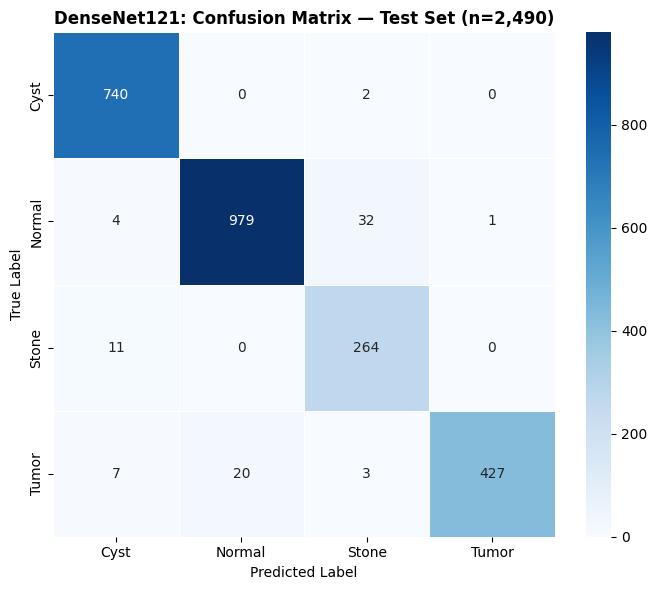

In [ ]:
# CONFUSION MATRIX
cm_dn = confusion_matrix(y_true_dn, y_pred_dn)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_dn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax)
ax.set_title('DenseNet121: Confusion Matrix — Test Set (n=2,490)', fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
fig.savefig(f"{PLOTS_PATH}/11_densenet121_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

## 10.9 Per-Class Metrics

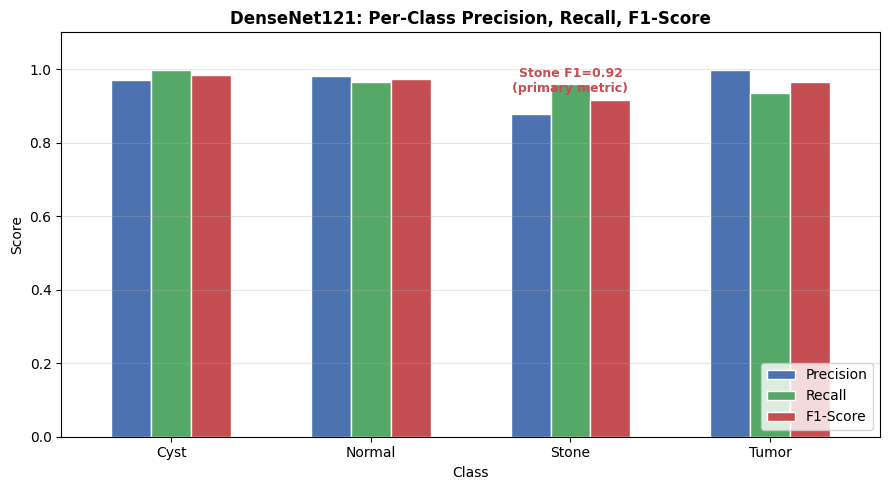

In [ ]:
# PER-CLASS METRICS
metrics_dn = pd.DataFrame({
    cls: [report_dn[cls]['precision'], report_dn[cls]['recall'], report_dn[cls]['f1-score']]
    for cls in class_names
}, index=['Precision', 'Recall', 'F1-Score']).T

fig, ax = plt.subplots(figsize=(9, 5))
metrics_dn.plot(kind='bar', ax=ax,
                color=['#4C72B0', '#55A868', '#C44E52'], width=0.6, edgecolor='white')
ax.set_title('DenseNet121: Per-Class Precision, Recall, F1-Score', fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Score')
ax.set_xticklabels(class_names, rotation=0)
ax.set_ylim(0, 1.1); ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)

# Annotate Stone F1
stone_idx = class_names.index('Stone')
ax.annotate(f'Stone F1={dn_stone_f1:.2f}\n(primary metric)',
           xy=(stone_idx, dn_stone_f1 + 0.02),
           fontsize=9, ha='center', color='#C44E52', fontweight='bold')

plt.tight_layout()
fig.savefig(f"{PLOTS_PATH}/12_densenet121_per_class_metrics.png", dpi=150, bbox_inches='tight')
plt.show()